In [22]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [23]:
df = pd.read_excel("/content/Sales_Analysis_Dataset.xlsx")

In [24]:
print(df.head())

   Order_ID Order_Date Customer_Name Customer_Segment Product_Name  \
0  ORD00001 2023-08-17     Suresh 90      Home Office       Laptop   
1  ORD00002 2023-03-03    Suresh 430         Consumer      Monitor   
2  ORD00003 2024-07-23     Sneha 105         Consumer       Laptop   
3  ORD00004 2025-01-05      Vijay 81      Home Office   Headphones   
4  ORD00005 2025-01-10     Priya 876         Consumer      Pen Set   

     Category Sub_Category Region        City  Quantity  ...      Sales  \
0  Technology    Computers   East      Ranchi         4  ...  195496.56   
1  Technology  Accessories  North  Chandigarh         4  ...   59495.44   
2  Technology    Computers  North  Chandigarh         7  ...  415866.46   
3  Technology  Accessories   East       Patna         1  ...    2324.90   
4  Stationery      Writing  North       Delhi         2  ...     292.28   

      Profit  Payment_Method  Year Month  Month_Number Quarter  Profit_Margin  \
0   44744.06             UPI  2023   Aug       

In [25]:
print("Shape:", df.shape)

Shape: (5000, 22)


In [26]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment',
       'Product_Name', 'Category', 'Sub_Category', 'Region', 'City',
       'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit',
       'Payment_Method', 'Year', 'Month', 'Month_Number', 'Quarter',
       'Profit_Margin', 'Unnamed: 20', 'Unnamed: 21'],
      dtype='object')


In [27]:
X = df[
    [
        "Quantity",
        "Unit_Price",
        "Discount",
        "Profit",
        "Profit_Margin",
        "Year",
        "Month_Number"
    ]
]

y = df["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Quantity  Unit_Price  Discount     Profit  Profit_Margin  Year  \
0         4    59602.61      0.18   44744.06          22.89  2023   
1         4    15024.10      0.01    7362.22          12.37  2023   
2         7    61884.89      0.04  120845.34          29.06  2024   
3         1     2672.30      0.13     683.72          29.41  2025   
4         2      155.47      0.06      41.99          14.37  2025   

   Month_Number  
0             8  
1             3  
2             7  
3             1  
4             1  

Target:
0    195496.56
1     59495.44
2    415866.46
3      2324.90
4       292.28
Name: Sales, dtype: float64


In [28]:
print(X.isnull().sum())
print(y.isnull().sum())

Quantity         0
Unit_Price       0
Discount         0
Profit           0
Profit_Margin    0
Year             0
Month_Number     0
dtype: int64
0


In [29]:
X = X.fillna(X.median())
y = y.fillna(y.median())

print("Missing values handled.")

Missing values handled.


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 7)
Testing data: (1000, 7)


In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [32]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [39]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 13302037504.0000 - mae: 58697.7891 - val_loss: 16003338240.0000 - val_mae: 68054.7969
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13293588480.0000 - mae: 58665.1836 - val_loss: 15981515776.0000 - val_mae: 67984.3594
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13257572352.0000 - mae: 58548.7383 - val_loss: 15912642560.0000 - val_mae: 67789.7969
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13170628608.0000 - mae: 58294.0703 - val_loss: 15768523776.0000 - val_mae: 67404.9375
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13012519936.0000 - mae: 57848.6289 - val_loss: 15529882624.0000 - val_mae: 66778.5781
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12770578432.0000 - mae: 57186.7656 - val_loss: 15189287936.0000 - val_mae: 65906.6719
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12437289984.0000 - mae: 56301.7734 - val_loss: 14732877824.0000 

In [34]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", loss)
print("Test MAE:", mae)

Test Loss: 14569444352.0
Test MAE: 63603.125


In [35]:
y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred[:10])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Predicted Sales:
[[0.13558467]
 [0.32457766]
 [0.33989885]
 [0.17069443]
 [0.22527418]
 [0.09480939]
 [0.46536386]
 [0.42033792]
 [0.4007667 ]
 [0.31832308]]


In [36]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 63603.12589833434
MSE: 14569442937.233671
RMSE: 120703.94747991332
R² Score: -0.3843915463362506


In [37]:
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred.flatten()
})

print(results.head(10))

   Actual Sales  Predicted Sales
0      24852.10         0.135585
1     492568.78         0.324578
2      50784.48         0.339899
3       5186.46         0.170694
4     164672.46         0.225274
5     195823.16         0.094809
6      52471.86         0.465364
7      21966.33         0.420338
8       9830.41         0.400767
9      87008.77         0.318323


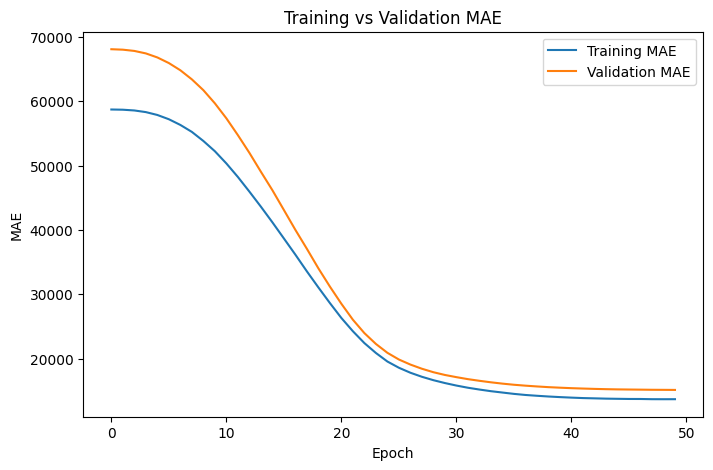

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()

plt.show()

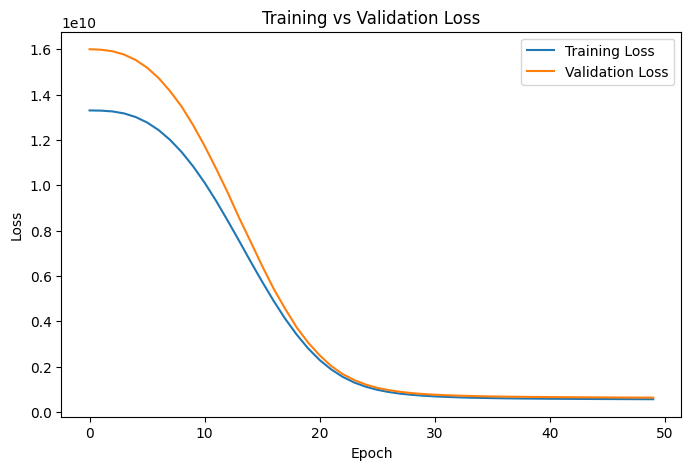

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

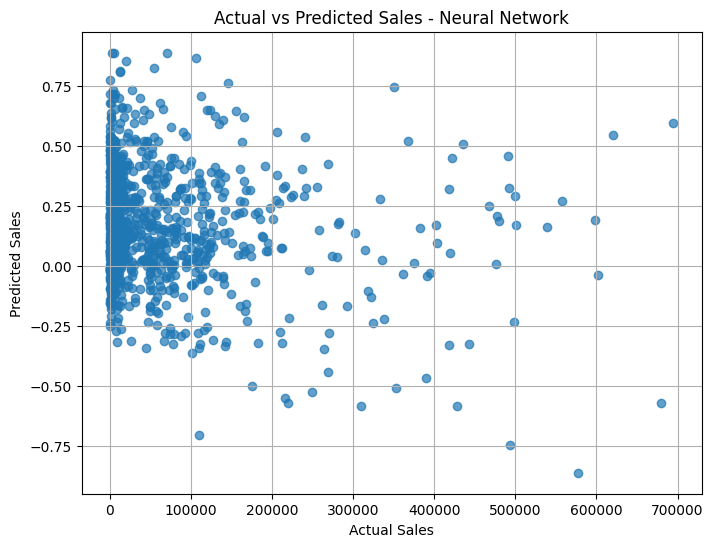

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred.flatten(),
    alpha=0.7
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales - Neural Network")

plt.grid(True)

plt.show()

In [43]:
results.to_excel(
    "Neural_Network_Sales_Predictions.xlsx",
    index=False
)

print("Prediction results saved successfully.")

Prediction results saved successfully.


In [45]:
model.save("sales_neural_network_model.keras")

print("Model saved successfully.")

Model saved successfully.
